In [1]:
import cv2
from mtcnn import MTCNN
from keras_facenet import FaceNet
import numpy as np
import matplotlib.pyplot as plt

img_target = cv2.imread(f'/mnt/windows_d/Xly_anh_va_thi_giac_mt/IPCV_Group3_Lab/lab05/my_image.jpeg')
img_target = cv2.cvtColor(img_target, cv2.COLOR_BGR2RGB)


I0000 00:00:1775660350.984305   94593 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775660351.041421   94593 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775660355.843958   94593 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


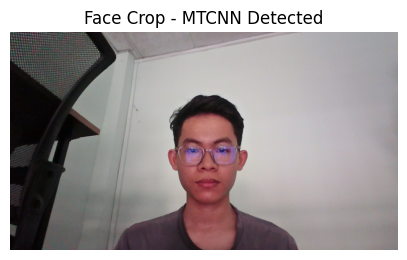

In [2]:

# Hiển thị ảnh face_crop
plt.figure(figsize=(5, 5)) # Thiết kế kích thước khung hình
plt.imshow(img_target)
plt.title("Face Crop - MTCNN Detected")
plt.axis('off') # Tắt trục tọa độ x, y để ảnh trông sạch hơn
plt.show()

In [3]:
# Khởi tạo object
detector = MTCNN()  # Phát hiện vị trí khuôn mặt
embedder = FaceNet()    # Trích xuất đặc trưng, biến hình khuôn mặt thành một dãy vector




target_face_info = detector.detect_faces(img_target)    # Tìm tọa độ khuôn mặt

if target_face_info:
    x, y, w, h = target_face_info[0]['box']
    # Đảm bảo tọa độ không âm (tránh lỗi cắt ảnh)
    x, y = max(0, x), max(0, y)
    face_crop = img_target[y:y+h, x:x+w]
    
    # Trích xuất embedding
    face_data = embedder.extract(face_crop, threshold=0.7)
    
    if len(face_data) > 0:
        target_embedding = face_data[0]['embedding']
        print("Đã khởi tạo embedding mục tiêu thành công!")
    else:
        print("Lỗi: FaceNet không thể trích xuất đặc trưng từ khuôn mặt trong ảnh mẫu.")
        exit() # Dừng chương trình vì không có dữ liệu mẫu để so sánh
else:
    print("Lỗi: MTCNN không tìm thấy khuôn mặt nào trong ảnh my_face.jpg.")
    exit()




E0000 00:00:1775660365.624542   94593 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Đã khởi tạo embedding mục tiêu thành công!


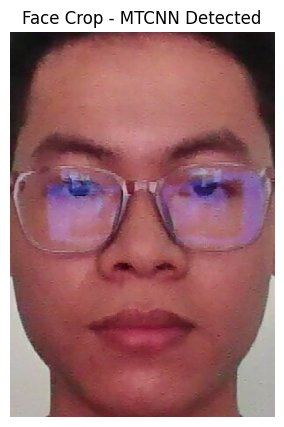

In [4]:

# Hiển thị ảnh face_crop
plt.figure(figsize=(5, 5)) # Thiết kế kích thước khung hình
plt.imshow(face_crop)
plt.title("Face Crop - MTCNN Detected")
plt.axis('off') # Tắt trục tọa độ x, y để ảnh trông sạch hơn
plt.show()

In [ ]:
cap = cv2.VideoCapture(0) # Mở webcam mặc định

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Chuyển BGR sang RGB cho MTCNN
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # 1. Phát hiện khuôn mặt bằng MTCNN
    results = detector.detect_faces(rgb_frame)

    for res in results:
        x, y, w, h = res['box']
        # Vẽ khung bao khuôn mặt
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

        # 2. Trích xuất đặc trưng vùng mặt vừa tìm được
        face_crop = rgb_frame[y:y+h, x:x+w]
        if face_crop.size > 0:
            face_data = embedder.extract(face_crop, threshold=0.95)
            
            if face_data:
                current_embedding = face_data[0]['embedding']
                
                # 3. So sánh bằng Cosine Similarity (hoặc Euclidean Distance)
                # FaceNet của keras-facenet thường dùng tính toán khoảng cách
                def compute_similarity(v1, v2):
                    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

                similarity = compute_similarity(target_embedding, current_embedding)

                # 4. Điều kiện so sánh theo yêu cầu lab
                label = f"Matched: {similarity:.2f}" if similarity > 0.7 else "Unknown"
                color = (0, 255, 0) if similarity > 0.7 else (0, 0, 255)

                cv2.putText(frame, label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    cv2.imshow("Face Recognition Lab", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


QFontDatabase: Cannot find font directory /mnt/windows_d/Xly_anh_va_thi_giac_mt/IPCV_Group3_Lab/venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /mnt/windows_d/Xly_anh_va_thi_giac_mt/IPCV_Group3_Lab/venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /mnt/windows_d/Xly_anh_va_thi_giac_mt/IPCV_Group3_Lab/venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /mnt/windows_d/Xly_anh_va_thi_giac_mt/IPCV_Group3_Lab/venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (fro

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━

KeyboardInterrupt: 

: 

/mnt/windows_d/Xly_anh_va_thi_giac_mt/IPCV_Group3_Lab/lab05
